# Laporan Proyek Sains Data 2

## Pendahuluan

### Latar Belakang

Emas merupakan salah satu komoditas yang memiliki peran penting dalam perekonomian global. Selain digunakan sebagai alat investasi yang stabil, emas juga digunakan dalam berbagai industri, seperti perhiasan, elektronik, dan kesehatan. Fluktuasi harga emas sering kali dipengaruhi oleh berbagai faktor, termasuk kondisi pasar global, nilai tukar mata uang, tingkat inflasi, dan situasi geopolitik. Oleh karena itu, kemampuan untuk memprediksi harga emas menjadi sangat penting, terutama bagi para investor, perusahaan, dan institusi keuangan dalam mengambil keputusan strategis.

Investasi emas telah menjadi salah satu pilihan populer di Indonesia karena stabilitas nilai emas dalam jangka panjang. Untuk mendukung pengambilan keputusan dalam investasi emas, diperlukan model prediksi yang mampu memperkirakan harga emas berdasarkan data historis.

### Masalah

Fluktuasi harga emas yang dipengaruhi oleh banyak faktor sering kali membuat investor kesulitan untuk memprediksi perubahan harga emas secara akurat. Ketidaktepatan dalam memprediksi harga emas dapat menyebabkan keputusan investasi yang kurang optimal. Selain itu, tidak semua investor memiliki akses terhadap alat prediksi berbasis teknologi yang mudah digunakan. Oleh karena itu, diperlukan model prediksi yang akurat dan berbasis data yang dapat membantu investor dalam mengambil keputusan.

### Tujuan

Tujuan dari proyek ini adalah:

1. Membuat model prediksi harga emas berbasis data historis.
2. Menghasilkan sebuah aplikasi sederhana yang dapat digunakan untuk memprediksi harga emas secara real-time.



## Metodologi

### Memahami Data (Data Understanding)

#### Pengumpulan Data

Data historis emas didapatkan dari API Pluang yang terupdate secara realtime. Menggunakan data historis emas kurang lebih selama 5 tahun

##### Mengambil Data

Mendapatkan data dari link API

In [20]:
#Get data from API link
import requests
import json

url = 'https://api-pluang.pluang.com/api/v3/asset/gold/pricing?daysLimit=1825'  # Ganti dengan URL API kamu

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    print("Berhasil mengambil data. Status", response.status_code)
else:
    print("Gagal mengambil data. Status:", response.status_code)

Berhasil mengambil data. Status 200


Membersihkan data dan mengubahnya ke dalam bentuk dataframe

In [21]:
#Clean JSON data
import pandas as pd

history_df = pd.json_normalize(data['data']['history'])

new_df = history_df[['updated_at', 'sell', 'buy']]

new_df['date'] = new_df['updated_at'].str.split('T').str[0]
temp_df = new_df[['date', 'sell', 'buy']]
temp_df.head()

C:\Users\atsuga\AppData\Local\Temp\ipykernel_11648\723975748.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['date'] = new_df['updated_at'].str.split('T').str[0]


,date,sell,buy
0,2024-12-09,1464560,1427946
1,2024-12-08,1483925,1446826
2,2024-12-07,1483925,1446826
3,2024-12-06,1484337,1447228
4,2024-12-05,1484363,1447253


#### Deskripsi Data

Data saham berupa csv berisikan 1606 baris dan 3 kolom yang merupakan :

- Date : Tanggal harga emas yang berformat yyyy-mm-dd hh:mm:ss
- Sell : Harga jual emas dalam Rupiah
- Buy : Harga beli emas dalam Rupiah


Melihat tipe data dari masing masing kolom.


In [22]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    1606 non-null   object
 1   sell    1606 non-null   int64 
 2   buy     1606 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 37.8+ KB


Terbaca bahwa dari 1606 baris data tiap kolomnya tidak ada baris yang kosong (null).


#### Eksplorasi Data

Sebelum melanjutkan eksplorasi data, terlebih dahulu menjadikan kolom date atau tanggal sebagai index dari data agar memudahkan prosesnya, serta hanya menggunakan kolom sell atau harga jual karena hanya akan memprediksi harga jual emas berdasarkan data harga jual emas di hari hari sebelumnya.


In [23]:
df = temp_df[['date', 'sell']]
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='%Y-%m-%d').dt.date
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.tail(10)

C:\Users\atsuga\AppData\Local\Temp\ipykernel_11648\1953931231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='%Y-%m-%d').dt.date


,sell
date,
2024-11-30,1474054
2024-12-01,1474054
2024-12-02,1472537
2024-12-03,1477532
2024-12-04,1475570
2024-12-05,1484363
2024-12-06,1484337
2024-12-07,1483925
2024-12-08,1483925


Dengan menjadikan date atau tanggal sebagai index data, dapat memudahkan data untuk diplot

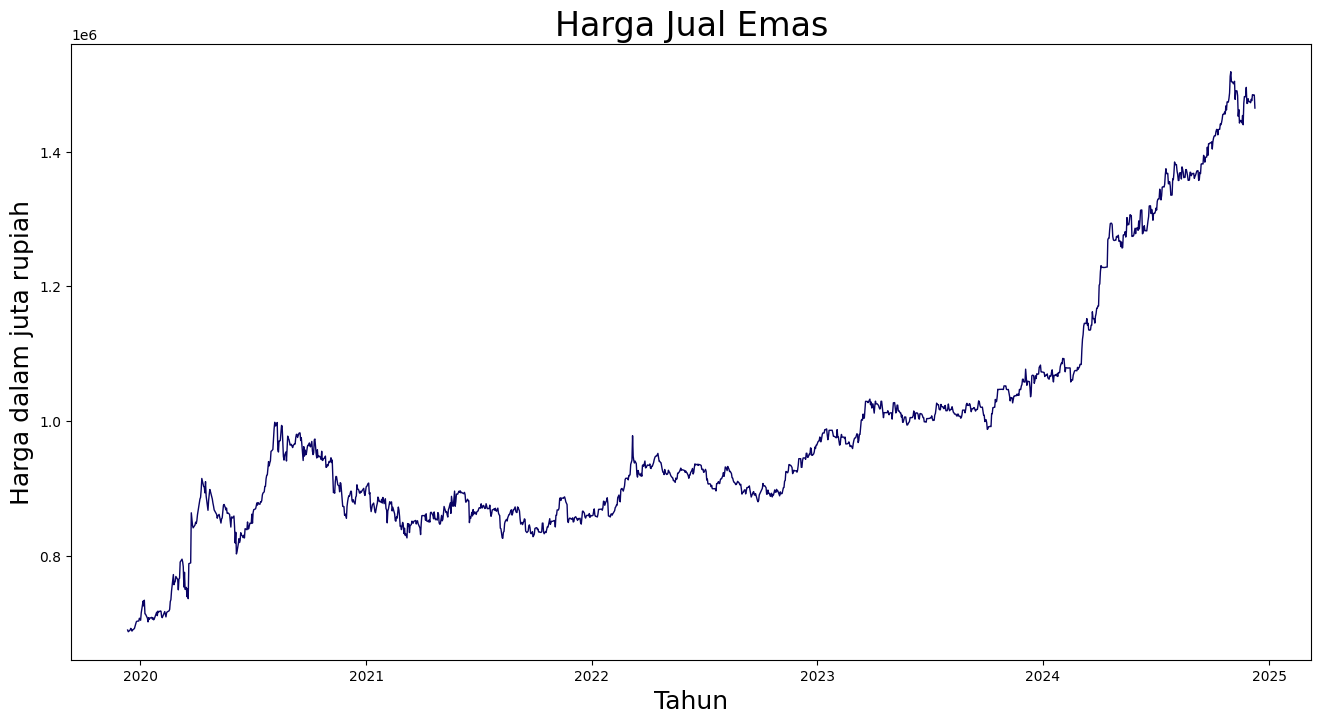

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title("Harga Jual Emas", fontsize=24)
plt.ylabel('Harga dalam juta rupiah', fontsize=18)
plt.xlabel('Tahun', fontsize=18)
sns.set_palette(["#090364", "#1960EF", "#EF5919"])
sns.lineplot(data=df['sell'], linewidth=1.0, dashes=False, ax=ax1)
plt.show()

Terlihat bahwa data jual emas relatif stabil dan naik dari tahun ke tahun, yang awalnya hanya berharga 800 ribuan di tahun 2020, hingga berharga kurang dari 1 juta 500 ribu diakhir tahun 2024. Selanjutnya melihat apakah data terdapat outlier

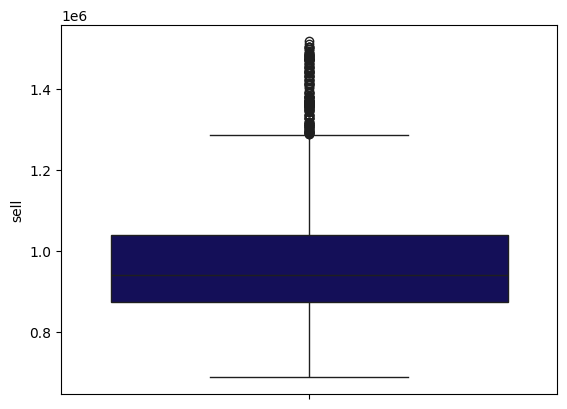

In [25]:
import numpy as np
sns.boxplot(df['sell'])
plt.show()

Terlihat jika terdapat banyak data yang terdeksi sebagai outlier, namun data tersebut tidak akan dihilangkan atau dinormalkan karena itu bukan data error dan data asli yang akan mempengaruhi prediksi jika data tersebut diubah. Karena data merupakan data univariate, maka tidak ada pengecekan korelasi antar fitur.

#### Verifikasi Kualitas Data

Dapat disimpulkan bahwa data yang digunakan terbilang bagus dan cocok untuk dipakai dalam modelling, namun perlu diperhatikan bahwa data perlu masuk ke tahap preprocessing data agar data benar benar siap untuk masuk ke tahap modelling.

### Pra-pemrosesan Data (Data Preprocessing)

#### Normalisasi Data

Melakukan scaling menggunakan Min-Max Scaling yaitu mengubah data sehingga semua nilai berada dalam rentang [0, 1] dengan rumus berikut

$$
x' = \frac{x - \text{min}(X)}{\text{max}(X) - \text{min}(X)}
$$

Di mana:

- $x'$ adalah nilai yang dinormalisasi.
- $x$ adalah nilai asli dari fitur.
- $\text{min}(X)$ adalah nilai minimum dari fitur dalam dataset.
- $\text{max}(X)$ adalah nilai maksimum dari fitur dalam dataset.

Min-Max Scaling berguna untuk meningkatkan kinerja model

In [26]:
import numpy as np

def normalize(df):
    from sklearn.preprocessing import RobustScaler, MinMaxScaler

    np_data_unscaled = np.array(df)
    scaler = MinMaxScaler()
    np_data_scaled = scaler.fit_transform(np_data_unscaled)
    print(np_data_unscaled)
    normalized_df = pd.DataFrame(np_data_scaled, columns=df.columns, index=df.index)
    pd.set_option('display.float_format', '{:.4f}'.format)  # Menampilkan 4 desimal
    return normalized_df, scaler

normalized_df, scaler = normalize(df)
normalized_df

[[ 690099]
 [ 687606]
 [ 690059]
 ...
 [1483925]
 [1483925]
 [1464560]]


,sell
date,
2019-12-12,0.0030
2019-12-13,0.0000
2019-12-16,0.0030
2019-12-17,0.0060
2019-12-18,0.0048
...,...
2024-12-05,0.9589
2024-12-06,0.9589
2024-12-07,0.9584


Terlihat bahwa data hanya bernilai dari angka 0 hingga 1 setelah dinormalisasi.

#### Sliding Window

Untuk memprediksi harga emas hari esok, dibutuhkan data hari emas di hari ini, kemarin, dan 2 hari yang lalu. Sehingga dilakukan sliding window untuk menambahkan fitur atau kolom baru yang berisikan 3 hari data kemarin yang dibutuhkan untuk prediksi.

In [27]:
def sliding_window(data, lag):
    series = data['sell']
    result = pd.DataFrame()
    for l in lag:
        result[f'sell-{l}'] = series.shift(l)

    result['sell'] = series[l:]
    result = result.dropna()
    result.index = series.index[l:]  # Mengatur index sesuai dengan nilai lag
    return result

windowed_data = sliding_window(normalized_df, [1, 2, 3])
windowed_data = windowed_data[['sell', 'sell-1', 'sell-2', 'sell-3']]
print(windowed_data)

             sell  sell-1  sell-2  sell-3
date                                     
2019-12-17 0.0060  0.0030  0.0000  0.0030
2019-12-18 0.0048  0.0060  0.0030  0.0000
2019-12-19 0.0012  0.0048  0.0060  0.0030
2019-12-20 0.0028  0.0012  0.0048  0.0060
2019-12-23 0.0058  0.0028  0.0012  0.0048
...           ...     ...     ...     ...
2024-12-05 0.9589  0.9483  0.9507  0.9447
2024-12-06 0.9589  0.9589  0.9483  0.9507
2024-12-07 0.9584  0.9589  0.9589  0.9483
2024-12-08 0.9584  0.9584  0.9589  0.9589
2024-12-09 0.9351  0.9584  0.9584  0.9589

[1603 rows x 4 columns]


#### Splitting Data

Sebelum masuk ke pemodelan, data dibagi terlebih dahulu. Data dibagi menjadi 2 yaitu 80% digunakan sebagai data train dan 20% sebagai data test. Dalam data train dan data test juga dibagi lagi menjadi data input yang berisikan data emas di 3 hari kemarin sebagai data prediksi dan data target yang merupakan data yang akan diprediksi. Hal ini dilakukan untuk mengetahui nilai error prediksi yang dihasilkan nanti.

In [28]:
def split_data(data, target, train_size):
    split_index = int(len(data) * train_size)

    x_train = data[:split_index]
    y_train = target[:split_index]
    x_test = data[split_index:]
    y_test = target[split_index:]

    return x_train, y_train, x_test, y_test

input_df = windowed_data[['sell-1', 'sell-2', 'sell-3']]
target_df = windowed_data[['sell']]

x_train, y_train, x_test, y_test = split_data(input_df, target_df, 0.8)

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1282, 3)
y_train shape: (1282, 1)
X_test shape: (321, 3)
y_test shape: (321, 1)


### Modelling

Terdapat beberapa skenario yang dilakukan untuk membandingkan nilai error yang dihasilkan dan memilih model dengan nilai error paling sedikit.

#### Regresi Linear tanpa Ensemble Bagging

##### Rumus Regresi Linear

Regresi linear dapat dinyatakan dengan rumus:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon 
$$

di mana:
- $y$ adalah variabel dependen (target).
- $\beta_0$ adalah intercept (konstanta).
- $\beta_1, \beta_2, \ldots, \beta_n$ adalah koefisien regresi untuk masing-masing variabel independen $x_1, x_2, \ldots, x_n$.
- $\epsilon$ adalah error atau residual.


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

#### Metrik Evaluasi Model

Metrik evaluasi model yang digunakan ada 3 yaitu : MSE, RMSE, dan MAPE

##### 1. MSE (Mean Squared Error)
- *Definisi*: MSE adalah rata-rata dari kuadrat selisih antara nilai yang diprediksi dan nilai aktual.
- *Rumus*:

  $
  \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $

  Di mana $y_i$ adalah nilai aktual, $\hat{y}_i$ adalah nilai prediksi, dan $n$ adalah jumlah data.

##### 2. RMSE (Root Mean Squared Error)
- *Definisi*: RMSE adalah akar kuadrat dari MSE, yang mengembalikan satuan ke skala yang sama dengan data asli.
- *Rumus*:

  $
  \text{RMSE} = \sqrt{\text{MSE}}
  $

##### 3. MAPE (Mean Absolute Percentage Error)
- *Definisi*: MAPE mengukur kesalahan dalam prediksi sebagai persentase dari nilai aktual.
- *Rumus*:

  $
  \text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%
  $

In [30]:
# Melakukan prediksi
y_pred = linear_model.predict(x_test)

# Menghitung error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Percentage Error (MAPE):", mape, " %")

Mean Squared Error (MSE): 0.0001235197688961699
Root Mean Squared Error (RMSE): 0.01111394479454392
Mean Absolute Percentage Error (MAPE): 0.010527842932727832  %


Skenario pertama dengan menggunakan model regresi linear biasa menghasilkan nilai error yang sangat kecil.

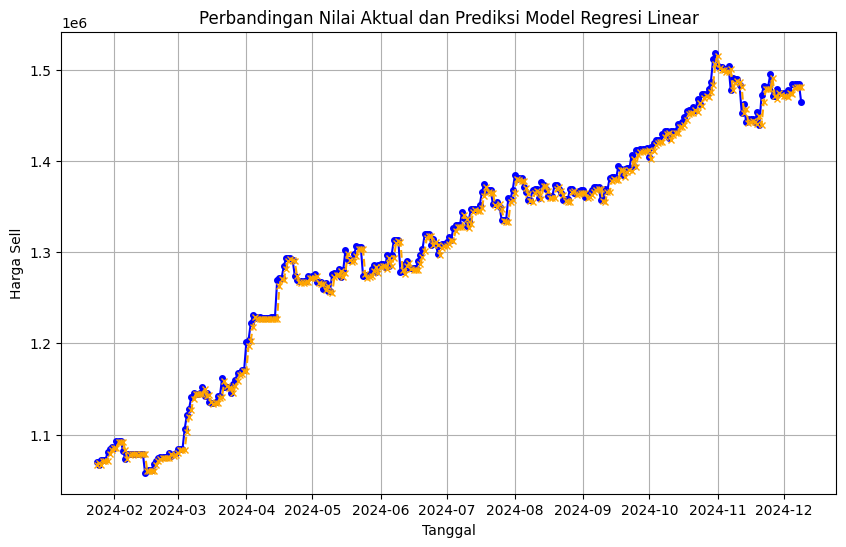

In [31]:
# Membuat grafik perbandingan
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, scaler.inverse_transform(y_test.values.reshape(-1, 1)), label='Aktual', color='blue', marker='o', linestyle='-', markersize=4)
plt.plot(y_test.index, scaler.inverse_transform(y_pred.reshape(-1, 1)), label='Prediksi', color='orange', marker='x', linestyle='--', markersize=4)
plt.title('Perbandingan Nilai Aktual dan Prediksi Model Regresi Linear')
plt.xlabel('Tanggal')
plt.ylabel('Harga Sell')
plt.grid()
plt.show()

In [32]:
last_row = windowed_data.iloc[-1][['sell-1', 'sell-2', 'sell-3']].values.reshape(1, -1)
predicted_value_normalized = linear_model.predict(last_row)
predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 1))

last_price = scaler.inverse_transform(normalized_df[['sell']].iloc[-1].values.reshape(-1, 1))
percentage_change = ((predicted_value[0][0] - last_price[0][0]) / last_price[0][0]) * 100

if percentage_change > 0:
    change_sign = '+'
else:
    change_sign = ''

print(f'Harga emas hari ini: {last_price[0][0]}')
print(f'Prediksi harga emas untuk hari esok: {predicted_value[0][0]} ({change_sign}{percentage_change:.2f}%)')

Harga emas hari ini: 1464560.0
Prediksi harga emas untuk hari esok: 1480802.4765943536 (+1.11%)


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Regresi Linear dengan Ensemble Bagging

Regresi Linear dengan Ensemble Bagging adalah pendekatan yang menggabungkan model regresi linear dengan teknik ensemble bagging untuk meningkatkan akurasi prediksi dan mengurangi variabilitas model.

Dalam regresi linear dengan bagging:

1. Data Sampling:

- Dataset asli dipecah menjadi beberapa subset dengan teknik bootstrap.
- Setiap subset berukuran sama dengan dataset asli tetapi mungkin memiliki data yang berulang.

2. Model Training:

- Model regresi linear independen dilatih pada setiap subset.

3. Model Aggregation:

- Hasil prediksi dari semua model diaggregasikan dengan rata-rata (averaging) untuk menghasilkan prediksi akhir.

In [33]:
from sklearn.ensemble import BaggingRegressor
base_model = LinearRegression()
bagging_model = BaggingRegressor(estimator=base_model, n_estimators=10, bootstrap=True)
bagging_model.fit(x_train, y_train)
y_pred = bagging_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape} %')

Mean Squared Error: 0.00012117865779267802
Root Mean Squared Error: 0.011008117813353835
Mean Absolute Percentage Error (MAPE): 0.01030746004391476 %


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_bagging.py:505: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


Terlihat MAPE yang dihasilkan sedikit lebih kecil daripada model regresi linear biasa, sehingga terbukti bahwa ensemble bagging mungkin dapat meningkatkan akurasi prediksi.

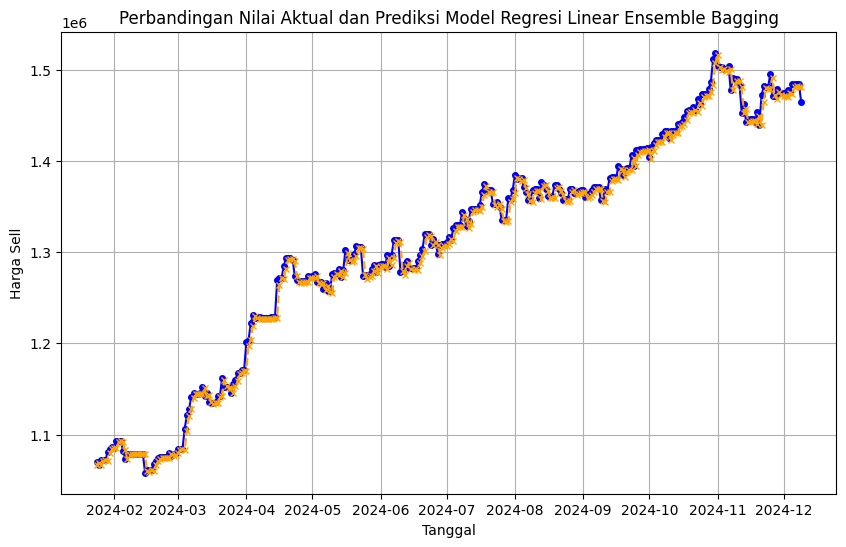

In [34]:
# Membuat grafik perbandingan
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, scaler.inverse_transform(y_test.values.reshape(-1, 1)), label='Aktual', color='blue', marker='o', linestyle='-', markersize=4)
plt.plot(y_test.index, scaler.inverse_transform(y_pred.reshape(-1, 1)), label='Prediksi', color='orange', marker='x', linestyle='--', markersize=4)
plt.title('Perbandingan Nilai Aktual dan Prediksi Model Regresi Linear Ensemble Bagging')
plt.xlabel('Tanggal')
plt.ylabel('Harga Sell')
plt.grid()
plt.show()

In [35]:
last_row = windowed_data.iloc[-1][['sell-1', 'sell-2', 'sell-3']].values.reshape(1, -1)
predicted_value_normalized = bagging_model.predict(last_row)
predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 1))
last_price = scaler.inverse_transform(normalized_df[['sell']].iloc[-1].values.reshape(-1, 1))
percentage_change = ((predicted_value[0][0] - last_price[0][0]) / last_price[0][0]) * 100
if percentage_change > 0:
    change_sign = '+'
else:
    change_sign = ''

print(f'Harga emas hari ini: {last_price[0][0]}')
print(f'Prediksi harga emas untuk hari esok: {predicted_value[0][0]} ({change_sign}{percentage_change:.2f}%)')

Harga emas hari ini: 1464560.0
Prediksi harga emas untuk hari esok: 1481048.032090074 (+1.13%)


C:\Users\atsuga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but BaggingRegressor was fitted with feature names
  warnings.warn(


### Grid Search

Skenario yang terakhir menggunakan grid search, Grid Search adalah teknik dalam pembelajaran mesin untuk mengoptimalkan hyperparameter model. Metode ini secara sistematis mencoba berbagai kombinasi hyperparameter yang didefinisikan dalam ruang pencarian (grid) dan mengevaluasi kinerja model menggunakan metrik tertentu, seperti akurasi, F1 score, atau mean squared error.

In [36]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def grid_search(input_df, target_df, splits, estimators, bootstrap, max_samples):
    best_rmse = float('inf')
    best_params = None
    i = 0
    for split in splits:
        x_train, y_train, x_test, y_test = split_data(input_df, target_df, split)
        for estimator in estimators:
            for bootstrap in bootstraps:
                for max_sample in max_samples:
                    base_model = LinearRegression()
                    bagging_model = BaggingRegressor(estimator=base_model, n_estimators=estimator, bootstrap=bootstrap, max_samples=max_sample)
                    bagging_model.fit(x_train, y_train.values.ravel())
                    y_pred = bagging_model.predict(x_test)
                    i+=1
                    current_rmse = rmse(y_test, y_pred)
                    #print(f'Model {i} split: {split}, estimator: {estimator}, bootstrap: {bootstrap}, max sample: {max_sample}, RMSE: {current_rmse}')
                    if current_rmse < best_rmse:
                        best_rmse = current_rmse
                        best_mse = mean_squared_error(y_test, y_pred)
                        best_mape = mean_absolute_percentage_error(y_test, y_pred)
                        best_model = bagging_model
                        best_params = {'estimator': estimator, 'bootstrap': bootstrap, 'train_sample': split, 'max_sample': max_sample}
                        y_test = y_test
                        y_pred = y_pred
    return best_params, best_rmse, best_mse, best_mape, best_model, y_test, y_pred

# Parameter untuk Grid Search
splits = [0.7, 0.75, 0.8, 0.85, 0.9]
estimators = [10, 20, 50, 100]
bootstraps = [True, False]
max_samples = [0.8, 0.9, 1.0]

best_params, best_rmse, best_mse, best_mape, best_model, y_test, y_pred = grid_search(input_df, target_df, splits, estimators, bootstraps, max_samples)

Dari 4 parameter yang bernilai beda beda tiap parameter dihasilkan 120 model, namun dari 120 model hanya dipilih 1 model dengan nilai RMSE paling minimal yang bernilai 0.0097

In [37]:
# Parameter terbaik
print(f'Best parameters: {best_params}')
print(f'Best RMSE: {best_rmse}')
print(f'Best MSE: {"{:.20f}".format(best_mse)}')
print(f'Best MAPE: {best_mape}')

Best parameters: {'estimator': 20, 'bootstrap': True, 'train_sample': 0.7, 'max_sample': 1.0}
Best RMSE: 0.010033842510981647
Best MSE: 0.00010067799553518249
Best MAPE: 0.01072618513896727


Model tersebut disimpan untuk nantinya digunakan saat deployment.

In [ ]:
# Membuat grafik perbandingan
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, scaler.inverse_transform(y_test.values.reshape(-1, 1)), label='Aktual', color='blue', marker='o', linestyle='-', markersize=4)
plt.plot(y_test.index, scaler.inverse_transform(y_pred.reshape(-1, 1)), label='Prediksi', color='orange', marker='x', linestyle='--', markersize=4)
plt.title('Perbandingan Nilai Aktual dan Prediksi Model Regresi Linear Ensemble Bagging terbaik')
plt.xlabel('Tanggal')
plt.ylabel('Harga Sell')
plt.grid()
plt.show()

#### Uji Coba

Uji coba prediksi dengan menggunakan model terbaik yang dihasilkan grid search.

In [ ]:
#sell_1 = int(input("Harga emas hari ini: "))
#sell_2 = int(input("Harga emas 1 hari sebelumnya: "))
#sell_3 = int(input("Harga emas 2 hari sebelumnya: "))

sell_1 = 1492738
sell_2 = 1432846
sell_3 = 1443278

last_row = np.array([
    scaler.transform([[sell_1]]).flatten()[0],
    scaler.transform([[sell_2]]).flatten()[0],
    scaler.transform([[sell_3]]).flatten()[0]
]).reshape(1, -1)
last_row_df = pd.DataFrame(last_row, columns=['sell-1', 'sell-2', 'sell-3'])
predicted_value_normalized = best_model.predict(last_row_df)
predicted_value = scaler.inverse_transform(predicted_value_normalized.reshape(-1, 1))
last_price = sell_1
percentage_change = ((predicted_value[0][0] - last_price) / last_price) * 100
change_sign = '+' if percentage_change > 0 else ''

formatted_predicted_value = f"{predicted_value[0][0]:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
formatted_last_price = f"{last_price:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print(f'Harga emas hari ini: Rp {formatted_last_price}')
print(f'Prediksi harga emas untuk hari esok: Rp {formatted_predicted_value} ({change_sign}{percentage_change:.2f}%)')

### Evaluation

Dari 3 skenario yang dilakukan saat pemodelan, dapat disimpulkan bahwa kombinasi parameter yang tepat dapat menghasilkan model dengan error minimum.

### Deployment

Project dideploy ke situs huggingface 

https://huggingface.co/spaces/atsuga/emas